# Compare data and simlulations for ghosts beams reference configurations
This notebook shows the refrence beam configurations for data taking to get the need set of ghosts.

In [1]:
%load_ext autoreload
%autoreload 


In [2]:
import timeit
import copy
import concurrent.futures 
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import batoid

from ghosts import plotter
from ghosts import simulator
from ghosts import tweak_optics
from ghosts import beam
from ghosts import geom


from ghosts.analysis import compute_ghost_separations, reduce_ghosts
from ghosts.analysis import match_ghosts, compute_reduced_distance, compute_2d_reduced_distance, find_nearest_ghost
from ghosts.analysis import make_data_frame

from ghosts.beam_configs import BEAM_CONFIG_0, BEAM_CONFIG_1, BEAM_CONFIG_3
from ghosts.geom_configs import GEOM_CONFIG_0
from ghosts.beam import rotate_config_to_ub

from ghosts.camera import build_camera, show_camera

## Build a basic telescope for debugging

In [3]:
# A few numbers, sepcific to 600 nm
beam_power_600nm = 13  # 13 Watt for the full spot according to measurements done in Grenoble
ccd_reflectivity_600nm = 0.141338
ccd_qe_600nm = 0.843274
lens_reflectivity_600nm = 0.004  # 0.4% code by Julien Bolmont
filter_reflectivity_600nm = 0.038  # r band filter documentation stated transmission is 96.2%

# CCOB like geometry, i.e. lenses but no filter
telescope = batoid.Optic.fromYaml("../data/LSST_CCOB_r.yaml")

# Make refractive interfaces partially reflective
# Call on current telescope, smart coating is [lens, filter, camera]
tweak_optics.make_optics_reflective(telescope, coating='smart',
                                    r_frac=[lens_reflectivity_600nm, filter_reflectivity_600nm, ccd_reflectivity_600nm])

0

In [4]:
# Ray trace one config for debugging
trace_full, r_forward, r_reverse, rays = simulator.run_simulation(telescope, beam_config=BEAM_CONFIG_1)
simulation = [trace_full, r_forward, r_reverse, rays]

# reduce ghosts
spots_data, _spots = reduce_ghosts(r_forward)
spots_data_frame = make_data_frame(spots_data)
gh_sep = compute_ghost_separations(spots_data_frame)

## Define a function to fully visualize a beam configuration and ghosts

In [5]:
def beam_test(telescope, beam_config):
    # Run simulation with standard beam config
    trace_full, r_forward, r_reverse, rays = simulator.run_simulation(telescope, beam_config=beam_config)
    simulation = [trace_full, r_forward, r_reverse, rays]
    # Check setup
    #plotter.plot_setup(telescope, simulation)

    # camera and ghosts visualization
    spots_data, _spots = reduce_ghosts(r_forward)
    spots_data_frame = make_data_frame(spots_data)
    _fig, _ax = plotter.plot_full_camera_and_spots(r_forward, spots_data_frame, log_scale=True)
    camera = build_camera()
    show_camera(_ax[1], camera)

    # pixel signal
    plt.rcParams["figure.figsize"] = [15, 6]
    fig, ax = plt.subplots(1, 2)
    axs = ax.flatten()
    spots_data_frame["pixel_signal_log"] = np.log10(spots_data_frame["pixel_signal"])
    #spots_data_frame.plot.bar("name", "pixel_signal_log")
    names = [f'{s}' for s in list(spots_data_frame["name"])]
    ax[0].bar(names, spots_data_frame["pixel_signal_log"])
    ax[0].set_xlabel("Ghost")
    ax[0].set_label("log10(pixel_signal)")
    ax[0].axhline(5, color="red")
    ax[0].tick_params(axis='x', labelrotation = 90)
    ax[0].axhline(1, color="black")
    ax[0].axhline(1.5, color="cyan")
    ax[0].set_title("Photons per pixel in each ghost spot\nfor a 100 nW beam of diameter 2.5 mm\nat 600 nm for a 1 s exposure")
    
    # ghosts separation
    gh_sep = compute_ghost_separations(spots_data_frame)
    ax[1].hist(gh_sep['distance']*1000, bins=20, range=[0., 10])
    ax[1].set_xlabel("Distance to ghosts (mm)")
    ax[1].set_label("Number")
    
    # zoom on ghosts
    plotter.plot_zoom_on_ghosts(r_forward)
    return r_forward, spots_data_frame

## Start building beam configurations chosen by hand

In [6]:
reference_beam_configurations = []

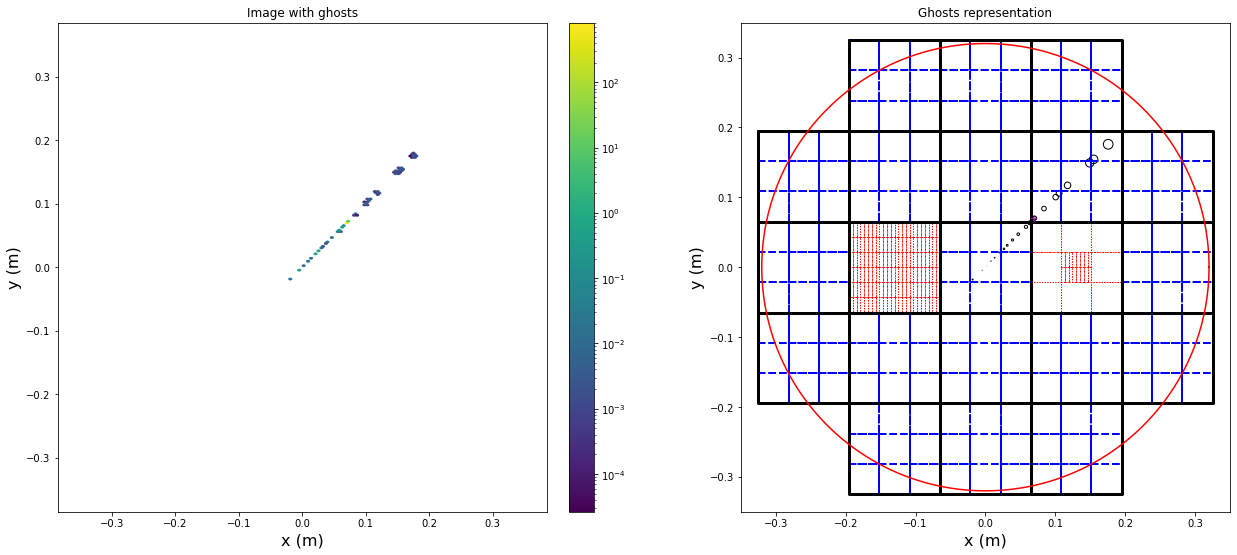

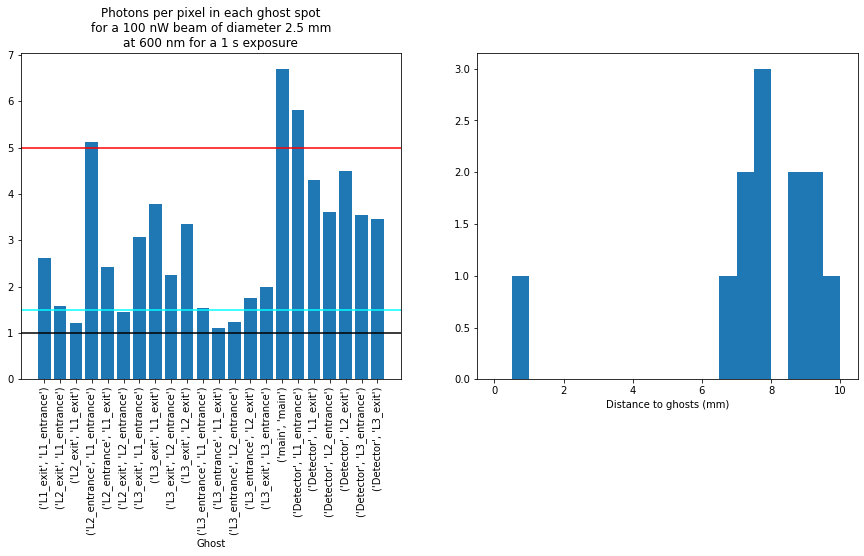

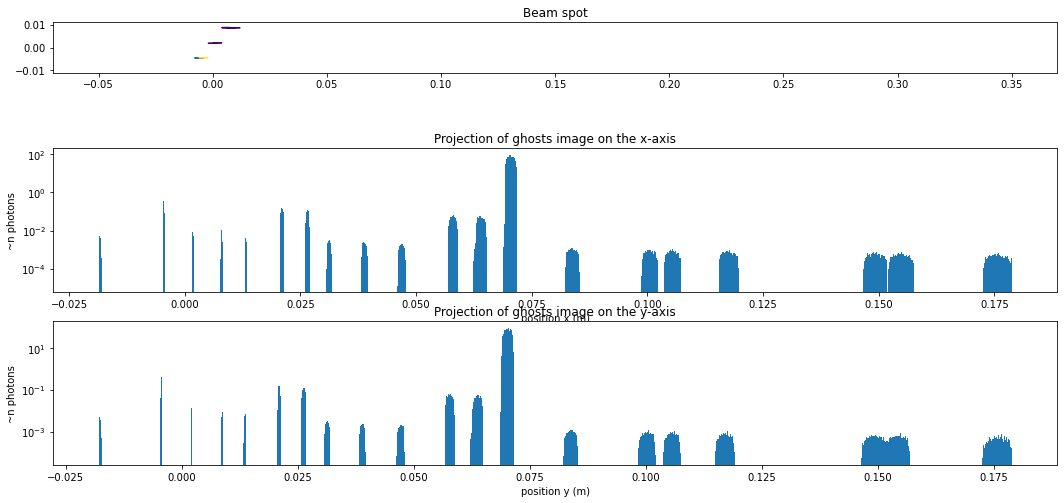

In [7]:
# Test beam - 1 degree - X
new_beam = copy.deepcopy(BEAM_CONFIG_0)
new_beam['beam_id'] = 999111
new_beam['x_offset'] = 0.07
new_beam['y_offset'] = 0.07
new_beam['x_euler'] = 0.
new_beam['y_euler'] = 0.
reference_beam_configurations.append(new_beam)
r_forward, spots_data_frame = beam_test(telescope, new_beam)

# Run 13439
- bregeon_step0x0a_none_band_sep225_0625

## 3023062500928

In [8]:
content = open("../data/bregeon_step0x0a_none_band_sep225_0625.cfg").readlines()
exp_id = 3023062500928
ld = []
for one in content:
    tok_list = one.split()
    dd = {"exposure_id": exp_id}    
    for tok in tok_list:
        kv = tok.split("=")
        dd[kv[0]] = kv[1]
    ld.append(dd)
    exp_id = exp_id + 1

configs_df = pd.DataFrame(ld)
configs_df.head()

,exposure_id,CCOBBCAM,CCOBBPOS,CCOBUCAM,CCOBUPOS,CCOBXCAM,CCOBXPOS,CCOBYCAM,CCOBYPOS,CCOB_L1S1_separation,...,expose,exptime,filter,id,lambda,plan_pd_current,rebs,sens,target_phot_per_pix,total_phots
0,3023062500928,-1.0000,2.0000,90.0000,91.3000,100,839.7573,6.54564934808159,800.9249,225,...,0.611,7,none,0xa003c700,500.000,1.5471e+00,"""R00,R01,R02,R03,R04,R10,R11,R12,R13,R14,R20,R...",R31_S20,139907.400963408,"5.8998e+09,"
1,3023062500929,-1.0000,2.0000,90.0000,91.3000,100,839.7573,6.54564934808159,800.9249,225,...,4.891,7,none,0xa003c710,500.000,1.5471e+00,"""R00,R01,R02,R03,R04,R10,R11,R12,R13,R14,R20,R...",R31_S20,1119946.15075618,"4.7227e+10,"
2,3023062500930,-0.697605274109277,1.6976,224.232281166335,225.5323,-100,1054.0843,-6.54564934808159,805.7887,225,...,0.611,7,none,0xa003c800,500.000,1.5471e+00,"""R00,R01,R02,R03,R04,R10,R11,R12,R13,R14,R20,R...",R31_S20,139907.400963408,"5.8998e+09,"
3,3023062500931,-0.697605274109277,1.6976,224.232281166335,225.5323,-100,1054.0843,-6.54564934808159,805.7887,225,...,4.891,7,none,0xa003c810,500.000,1.5471e+00,"""R00,R01,R02,R03,R04,R10,R11,R12,R13,R14,R20,R...",R31_S20,1119946.15075618,"4.7227e+10,"
4,3023062500932,-1.0000,2.0000,90.0000,91.3000,-100,1039.7058,6.54564934808159,805.4624,225,...,0.611,7,none,0xa003c900,500.000,1.5471e+00,"""R00,R01,R02,R03,R04,R10,R11,R12,R13,R14,R20,R...",R31_S20,139907.400963408,"5.8998e+09,"


In [9]:
conf_3023062500928 = configs_df[configs_df["exposure_id"]==3023062500928]
conf_3023062500928[["CCOBXCAM", "CCOBYCAM", "CCOBUCAM", "CCOBBCAM", "CCOBXPOS","CCOBYPOS", "CCOBUPOS", "CCOBBPOS"]].head()

#x_pos = conf_3023062500928["CCOBXPOS"]
#y_pos = conf_3023062500928["CCOBYPOS"]
#u_pos = conf_3023062500928["CCOBUPOS"]
#b_pos = conf_3023062500928["CCOBBPOS"]



,CCOBXCAM,CCOBYCAM,CCOBUCAM,CCOBBCAM,CCOBXPOS,CCOBYPOS,CCOBUPOS,CCOBBPOS
0,100,6.54564934808159,90.0000,-1.0000,839.7573,800.9249,91.3000,2.0000


In [10]:
# camera center (954.1, 789.0, 0.0, 1.0)
xcam = 839.7573 - 954.1 
ycam = 800.9249 - 789 
upos = 91.3 -1.3
bpos = 2 - 0.7
print(xcam, ycam)
new_beam = copy.deepcopy(BEAM_CONFIG_0)
new_beam['beam_id'] = 111111111
new_beam['n_photons'] = 100
new_beam = rotate_config_to_ub(new_beam, 90, -1.3)
new_beam

-114.34270000000004 11.92489999999998


{'beam_id': 111111111,
 'wl': 5e-07,
 'n_photons': 100,
 'radius': 0.00125,
 'x_offset': 0.0,
 'y_offset': 0,
 'z_offset': 2.7974726,
 'z_euler': 89.99999999999999,
 'y_euler': 1.3000000000000211,
 'x_euler': -0.7}

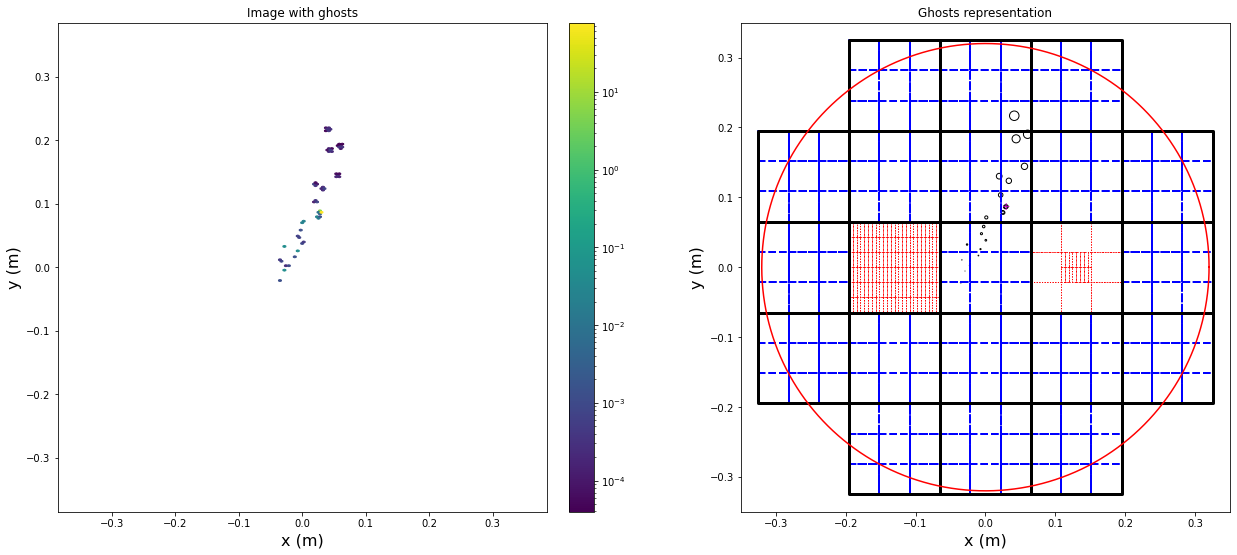

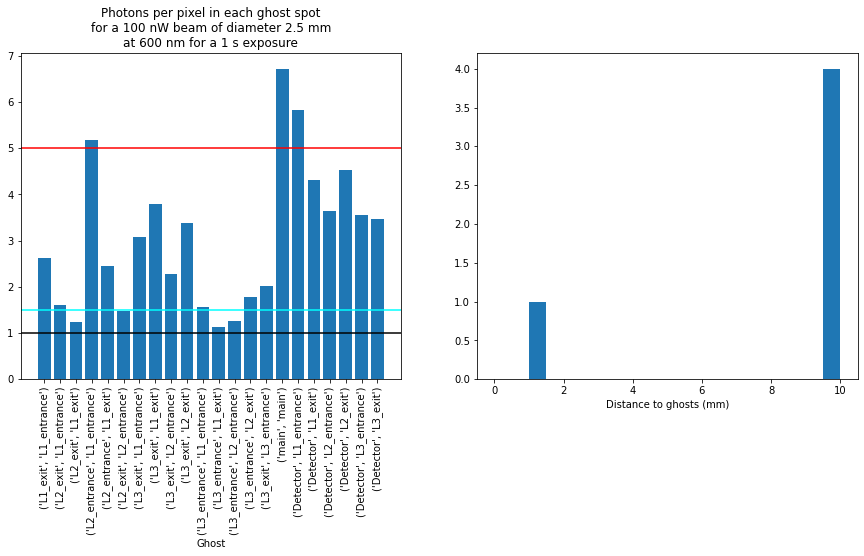

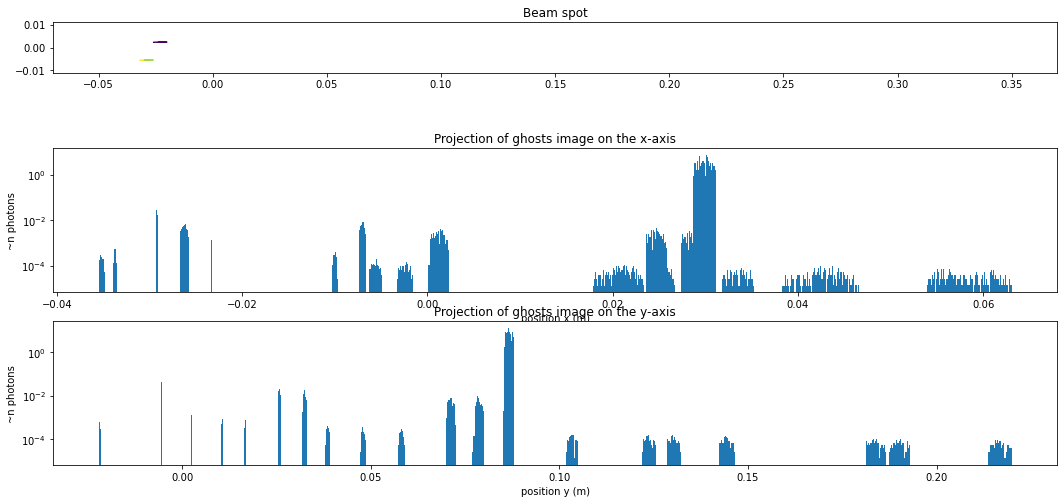

In [11]:
new_beam = copy.deepcopy(BEAM_CONFIG_0)
new_beam['beam_id'] = 3023062500928
new_beam['n_photons'] = 100
new_beam['x_offset'] = 57.653/1000. # 86.561/1000.   # 0.012 # 0.022 # -0.012  # -6.5/1000.
new_beam['y_offset'] = 86.561/1000. # 57.653/1000. # 0.114 # 0.26  #  0.114  #  100/1000.
new_beam['z_offset'] = 3.0680498  # 3.1974726  # 327.662
# new_beam = rotate_config_to_ub(new_beam, -26.6, -6.8)
new_beam['x_euler'] = 0
new_beam['y_euler'] = -1.2023112100001202311210000115  #-1.3
# 'y_euler': -6.085965858035159,
# 'x_euler': 3.039043790698078}
# new_beam = rotate_config_to_ub(new_beam, -26.6, -7.8)
# new_beam['x_euler'] = -6.983
# new_beam['y_euler'] = 3.483

#print(new_beam)
#new_beam['x_euler'] = -6.983
#new_beam['y_euler'] = 3.483
#new_beam['z_euler'] = -26.387
#reference_beam_configurations.append(new_beam)
rf928, sdf928 = beam_test(telescope, new_beam)


In [12]:
fpx, fpy = ([-12.67773840763679,
  -19.694566934846517,
  -35.13959887382687,
  -23.73211026233199,
  -32.016700548879925,
  -15.572644257409156,
  -41.1195516497345,
  -25.763404812259505,
  -16.749795615597833,
  -22.88101788150478,
  -26.404643479574844,
  -18.10170465427844,
  -32.5726684086302,
  -26.47461699916501,
  -38.94482039740597,
  -29.518520200366765],
 [89.74160001970806,
  26.18226955525206,
  -0.7952991635539729,
  -28.682172958194826,
  172.6349488525145,
  145.31863696347094,
  160.73305945597727,
  -11.23426341007049,
  40.59752118242526,
  -4.90910882678807,
  114.71913129922861,
  16.437410753769363,
  66.33213011475746,
  38.393348867326644,
  23.131579369573593,
  52.46764156887708])
fpxmm = np.array(fpx)/1000.
fpymm = np.array(fpy)/1000.

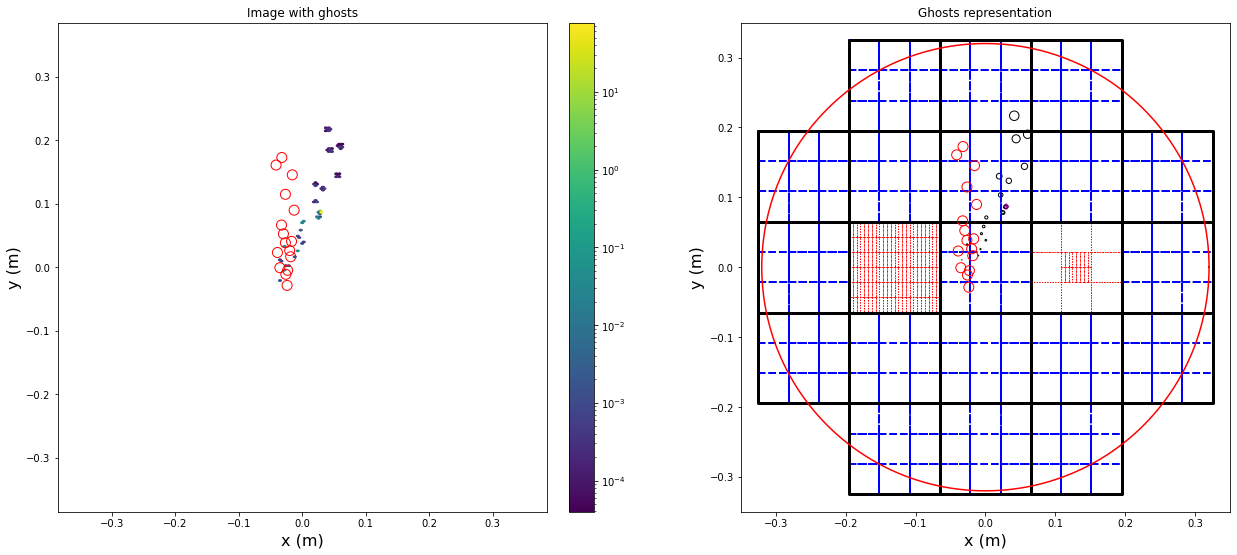

In [13]:
# Draw real ghosts spots on simulation
_mfig, _max = plotter.plot_full_camera_and_spots(rf928, sdf928, log_scale=True)
camera = build_camera()
show_camera(_max[1], camera)
_max[0].scatter(fpxmm, fpymm, s=100, facecolors='none', edgecolors='r', linewidths=1)
_max[1].scatter(fpxmm, fpymm, s=100, facecolors='none', edgecolors='r', linewidths=1)

<Axes: >

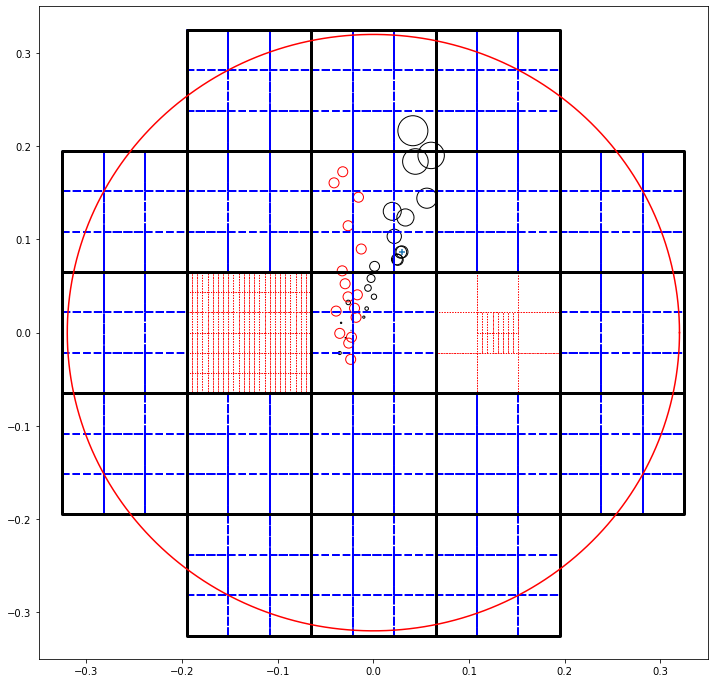

In [14]:
# Draw real ghosts spots on simulation
plt.rcParams["figure.figsize"] = [12, 12]
sfig, sax = plotter.plot_spots([sdf928], spot_size_scaling=100)
sax.scatter(fpxmm, fpymm, s=100, facecolors='none', edgecolors='r', linewidths=1)
# Plot approximate focal plane radius
th = np.linspace(0, 2 * np.pi, 1000)
plt.plot(0.32 * np.cos(th), 0.32 * np.sin(th), c='r')
camera = build_camera()
show_camera(sax, camera)


# Run 13579
## 2023112100001

In [15]:
import pandas as pd
new_beam_frame = pd.read_parquet("run_13579_beam_configs_v1.parquet")
new_beam_frame.head()

,beam_id,wl,n_photons,radius,x_offset,y_offset,z_offset,z_euler,y_euler,x_euler
20231121000001,20231121000001,5.000000e-07,100,0.00125,0.057653,0.086561,3.068050,-90.0,-1.15959,0.7
20231121000002,20231121000002,5.000000e-07,100,0.00125,0.057653,0.086561,3.068050,-90.0,-1.15959,0.7
20231121000003,20231121000003,5.000000e-07,100,0.00125,0.057653,0.086561,3.068050,-90.0,-1.15959,0.7
20231121000004,20231121000004,5.000000e-07,100,0.00125,0.048128,-0.113435,3.069689,-90.0,-3.15959,0.7
20231121000005,20231121000005,5.000000e-07,100,0.00125,0.048128,-0.113435,3.069689,-90.0,-3.15959,0.7


In [16]:
new_beam_frame[new_beam_frame['beam_id']=="20231121000001"]

,beam_id,wl,n_photons,radius,x_offset,y_offset,z_offset,z_euler,y_euler,x_euler
20231121000001,20231121000001,5.000000e-07,100,0.00125,0.057653,0.086561,3.06805,-90.0,-1.15959,0.7


In [17]:
from ghosts import beam
beam_conf = beam.to_dict((new_beam_frame[new_beam_frame['beam_id']=="20231121000006"]))
beam_conf

{'beam_id': '20231121000006',
 'wl': 5e-07,
 'n_photons': 100,
 'radius': 0.00125,
 'x_offset': 0.0481276,
 'y_offset': -0.11343500000000001,
 'z_offset': 3.069688882,
 'z_euler': -90.0,
 'y_euler': -3.1595900000000143,
 'x_euler': 0.7}

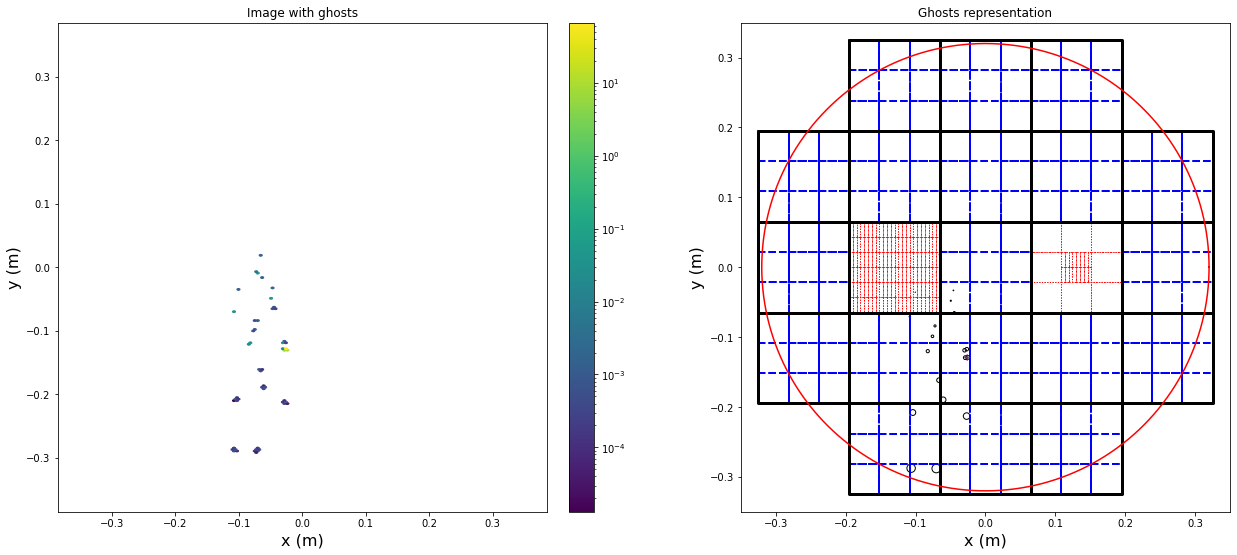

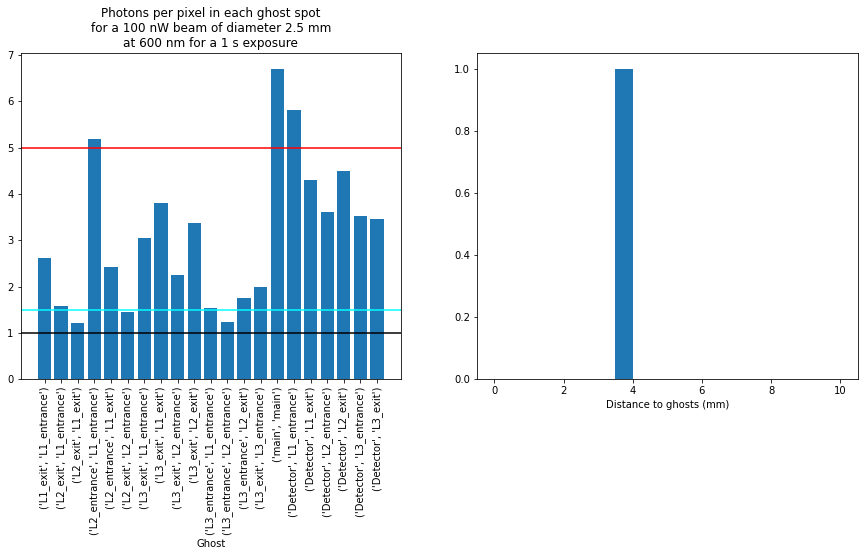

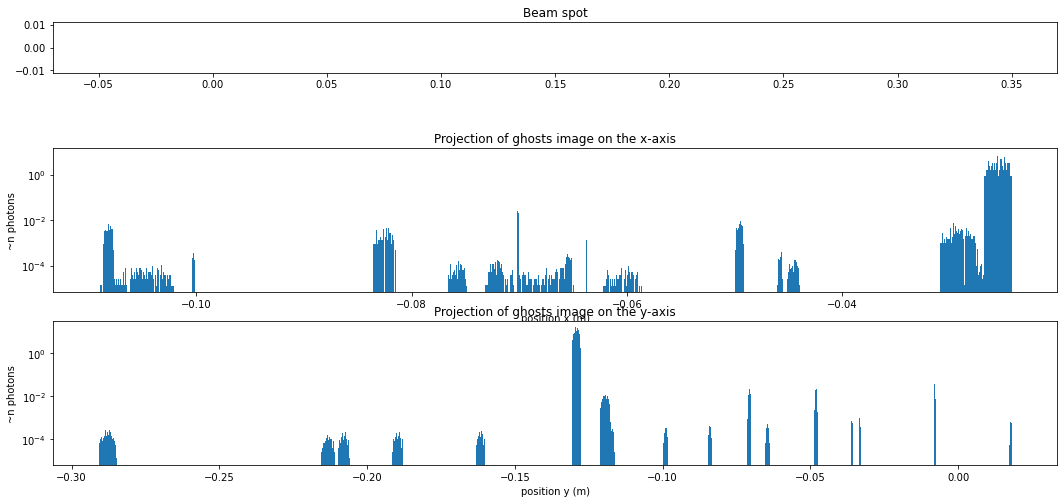

In [18]:
rf001, sdf001 = beam_test(telescope, beam_conf)

In [19]:
sdf001.sort_values("pos_y")

,beam_id,geom_id,index,name,pos_x,std_x,pos_y,std_y,width_x,width_y,radius,radius_err,flux,surface,n_pixels,pixel_signal,pixel_signal_log
2,0,0,2,"(L2_exit, L1_exit)",-0.070337,0.001406,-0.288064,0.001406,0.005436,0.005449,0.002721,6.396771e-06,0.001331,23.262680,209364,1.631579e+01,1.212608
11,0,0,11,"(L3_entrance, L2_entrance)",-0.106285,0.001373,-0.287599,0.001373,0.005301,0.005387,0.002672,4.305791e-05,0.001331,22.428416,201856,1.692268e+01,1.228469
5,0,0,5,"(L2_exit, L2_entrance)",-0.026871,0.001069,-0.213069,0.001069,0.004129,0.004191,0.002080,3.105704e-05,0.001341,13.592825,122335,2.814748e+01,1.449439
10,0,0,10,"(L3_entrance, L1_entrance)",-0.103814,0.000956,-0.207951,0.000956,0.003695,0.003674,0.001842,1.063169e-05,0.001309,10.663384,95970,3.502758e+01,1.544410
1,0,0,1,"(L2_exit, L1_entrance)",-0.060368,0.000908,-0.189682,0.000908,0.003512,0.003486,0.001750,1.295952e-05,0.001320,9.617933,86561,3.914757e+01,1.592705
12,0,0,12,"(L3_entrance, L2_exit)",-0.066350,0.000759,-0.161651,0.000759,0.002934,0.002919,0.001463,7.350689e-06,0.001341,6.726119,60535,5.688328e+01,1.754985
20,0,0,20,"(Detector, L3_exit)",-0.028655,0.000634,-0.129456,0.000634,0.002453,0.002435,0.001222,9.324804e-06,0.047391,4.691030,42219,2.881907e+03,3.459680
14,0,0,14,"(main, main)",-0.025459,0.000636,-0.129147,0.000636,0.002461,0.002443,0.001226,9.220442e-06,83.825910,4.721554,42494,5.064590e+06,6.704544
17,0,0,17,"(Detector, L2_entrance)",-0.082469,0.000524,-0.120131,0.000524,0.002026,0.002006,0.001008,9.899600e-06,0.046265,3.192883,28736,4.133530e+03,3.616321
19,0,0,19,"(Detector, L3_entrance)",-0.029800,0.000578,-0.118903,0.000578,0.002236,0.002225,0.001115,5.474399e-06,0.047013,3.908910,35180,3.430924e+03,3.535411


## 2023112100012

In [20]:
# Read real beam spots
real_spots = pd.read_parquet("../data/run_13579_exposure_2023112100006_ghosts_spots.parquet")
real_spots.head()

,bkg,height,x,y,width,exposure_id,ccd_name,ccd_id,ccd_x,ccd_y,rough_fpx,rough_fpy
0,-2384.895168,201818.642517,3661.881063,2386.218285,10.015275,2023112100006,R12_S10,48,3815.548503,2087.246278,-24.569515,-126.142537
1,0.400995,29.842965,3158.554707,3920.252439,7.307527,2023112100006,R21_S12,86,4038.937656,1659.519516,-64.835623,-3.419805
2,-3.132470,91.278886,3093.917850,3613.253228,12.959239,2023112100006,R21_S02,83,3521.842801,3428.525823,-70.006572,-27.979742
3,-0.196614,30.272224,3221.627309,3581.207179,9.987107,2023112100006,R22_S00,90,293.518469,3172.157435,-59.789815,-30.543426
4,0.329736,45.648244,3389.967645,3356.420739,8.875061,2023112100006,R22_S00,90,1640.241161,1373.865911,-46.322588,-48.526341


In [21]:
# A few numbers, sepcific to 600 nm
beam_power_600nm = 13  # 13 Watt for the full spot according to measurements done in Grenoble
ccd_reflectivity_600nm = 0.141338
ccd_qe_600nm = 0.843274
lens_reflectivity_600nm = 0.004  # 0.4% code by Julien Bolmont
filter_reflectivity_600nm = 0.038  # r band filter documentation stated transmission is 96.2%

# CCOB like geometry, i.e. lenses but no filter
telescope = batoid.Optic.fromYaml("../data/LSST_CCOB_r.yaml")

# Make refractive interfaces partially reflective
# Call on current telescope, smart coating is [lens, filter, camera]
tweak_optics.make_optics_reflective(telescope, coating='smart',
                                    r_frac=[lens_reflectivity_600nm, filter_reflectivity_600nm, ccd_reflectivity_600nm])

0

In [26]:
# Try to visualize beam configuration and ghosts
def read_config_for_run(run=13579):
    beam_configs_df = pd.read_parquet(f'run_{run}_beam_configs_v1.parquet')
    beam_configs_df.head()
    return beam_configs_df

def read_real_spots_for_run(run=13579, exposure_id="20231121000012"):
    exp_id = exposure_id[0:8]+exposure_id[9:]
    print(exp_id)
    real_spots = pd.read_parquet(f'../data/run_{run}_exposure_{exp_id}_ghosts_spots.parquet')
    real_spots.head()
    return real_spots

def simulate_ghost_config(telescope, beam_config, ax=None):
    # Run simulation with standard beam config
    trace_full, r_forward, r_reverse, rays = simulator.run_simulation(telescope, beam_config=beam_config)
    simulation = [trace_full, r_forward, r_reverse, rays]

    # reduce ghosts
    spots_data, _spots = reduce_ghosts(r_forward)
    spots_data_frame = make_data_frame(spots_data)
    
    # return figure and 
    return spots_data_frame

def draw_real_on_sim(sdf, real_spots, title="exposure"):
    plt.rcParams["figure.figsize"] = [12, 12]
    sfig, sax = plotter.plot_spots([sdf], spot_size_scaling=100)
    sax.scatter(real_spots.rough_fpx/1000., real_spots.rough_fpy/1000., s=100, facecolors='none', edgecolors='r', linewidths=1)
    sax.scatter(real_spots.rough_fpx[0]/1000., real_spots.rough_fpy[0]/1000., s=100, facecolors='none', edgecolors='orange')
    th = np.linspace(0, 2 * np.pi, 1000)
    plt.plot(0.32 * np.cos(th), 0.32 * np.sin(th), c='r')
    plt.title(title)
    camera = build_camera()
    show_camera(sax, camera)
    #plt.savefig(title+'.png')

def compare_real_data_and_simulations(run=13579, exposure_id="20231121000012"):
    # get beam configs for a given run from parquet file
    new_beam_frame = read_config_for_run(run)
    # select the beam config corresponding to the exposure
    beam_conf = beam.to_dict((new_beam_frame[new_beam_frame['beam_id']==exposure_id]))
    print(beam_conf)
    #beam_conf["x_euler"] = beam_conf["x_euler"]  # - math.sin(math.radians(beam_conf["z_euler"]))*0.7 
    #beam_conf["y_euler"] = beam_conf["y_euler"] # + math.cos(math.radians(beam_conf["z_euler"]))*0.7
    beam_conf["z_offset"] = beam_conf["z_offset"] + 0.05
    print(beam_conf)
    # simulate ghost config and get simulated ghosts positions
    from ghosts.tweak_optics import translate_optic
    #telescope_v314 = translate_optic(telescope, 'L1', axis='z', distance=0.04)
    #telescope_v314 = translate_optic(telescope_v314, 'L2', axis='z', distance=0.01)
    #telescope_v314 = translate_optic(telescope_v314, 'L3', axis='z', distance=-0.02)
    #tweak_optics.make_optics_reflective(telescope_v314)
    #sdf = simulate_ghost_config(telescope_v314, beam_conf)
    sdf = simulate_ghost_config(telescope, beam_conf)
    # read real ghosts spots position from parquet files
    real_spots = read_real_spots_for_run(run, exposure_id)
    # show match
    draw_real_on_sim(sdf, real_spots, exposure_id)


## Get Config

{'beam_id': '20231121000012', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': 0.113431, 'y_offset': -0.043736899999999995, 'z_offset': 3.069884882, 'z_euler': 180.0, 'y_euler': -0.7, 'x_euler': -3.1595899999999633}
{'beam_id': '20231121000012', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': 0.113431, 'y_offset': -0.043736899999999995, 'z_offset': 3.119884882, 'z_euler': 180.0, 'y_euler': -0.7, 'x_euler': -3.1595899999999633}
2023112100012


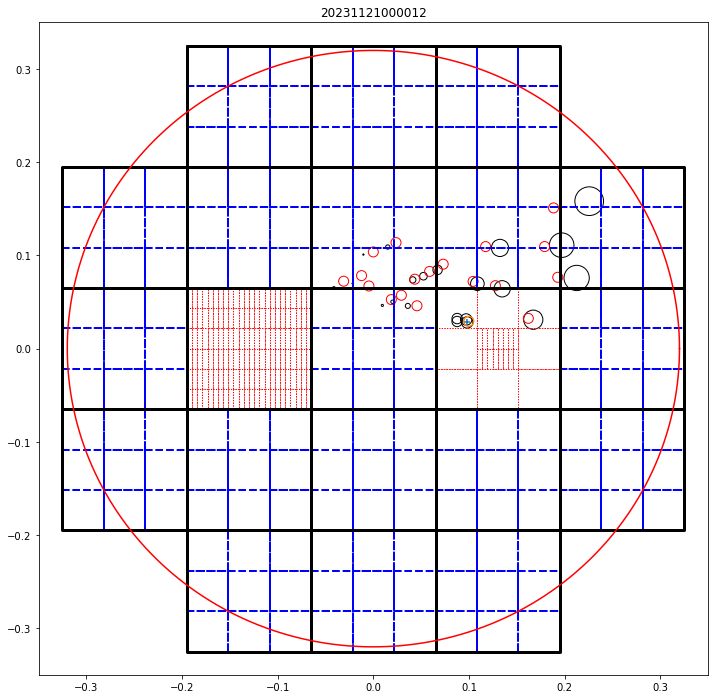

In [23]:
compare_real_data_and_simulations(run=13579, exposure_id="20231121000012")

20231121000003
{'beam_id': '20231121000003', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': 0.0576531, 'y_offset': 0.08656100000000001, 'z_offset': 3.0680498820000004, 'z_euler': -90.0, 'y_euler': -1.1595899999999861, 'x_euler': 0.7}
{'beam_id': '20231121000003', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': 0.0576531, 'y_offset': 0.08656100000000001, 'z_offset': 3.118049882, 'z_euler': -90.0, 'y_euler': -1.1595899999999861, 'x_euler': 0.7}
2023112100003
20231121000006
{'beam_id': '20231121000006', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': 0.0481276, 'y_offset': -0.11343500000000001, 'z_offset': 3.069688882, 'z_euler': -90.0, 'y_euler': -3.1595900000000143, 'x_euler': 0.7}
{'beam_id': '20231121000006', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': 0.0481276, 'y_offset': -0.11343500000000001, 'z_offset': 3.1196888819999997, 'z_euler': -90.0, 'y_euler': -3.1595900000000143, 'x_euler': 0.7}
2023112100006
20231121000009
{'b

/home/bregeon/Rubin/CCOB/ghosts/ghosts/analysis.py:210: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _fig, ax = plt.subplots(len(r_forward))


2023112100063


/home/bregeon/Rubin/CCOB/ghosts/ghosts/plotter.py:539: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 1)


20231121000066
{'beam_id': '20231121000066', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': -0.15193199999999998, 'y_offset': 0.18376900000000002, 'z_offset': 3.064602882, 'z_euler': -153.60097102943257, 'y_euler': 1.3976971435274281, 'x_euler': 4.38242614635385}
{'beam_id': '20231121000066', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': -0.15193199999999998, 'y_offset': 0.18376900000000002, 'z_offset': 3.114602882, 'z_euler': -153.60097102943257, 'y_euler': 1.3976971435274281, 'x_euler': 4.38242614635385}
2023112100066
20231121000069
{'beam_id': '20231121000069', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': -0.167365, 'y_offset': -0.214772, 'z_offset': 3.067912882, 'z_euler': 153.66312089620783, 'y_euler': 2.1344819528990593, 'x_euler': -5.869960524870934}
{'beam_id': '20231121000069', 'wl': 5e-07, 'n_photons': 100, 'radius': 0.00125, 'x_offset': -0.167365, 'y_offset': -0.214772, 'z_offset': 3.1179128819999997, 'z_euler': 153.66312089620

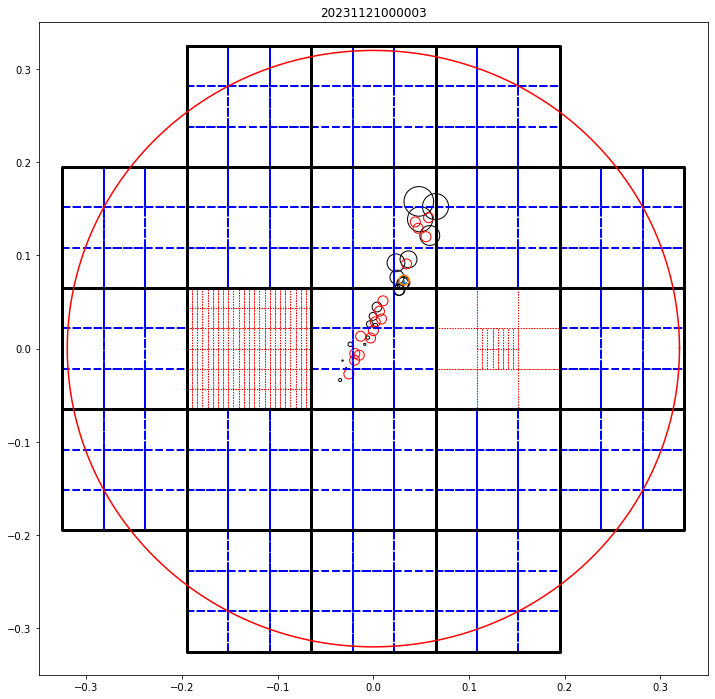

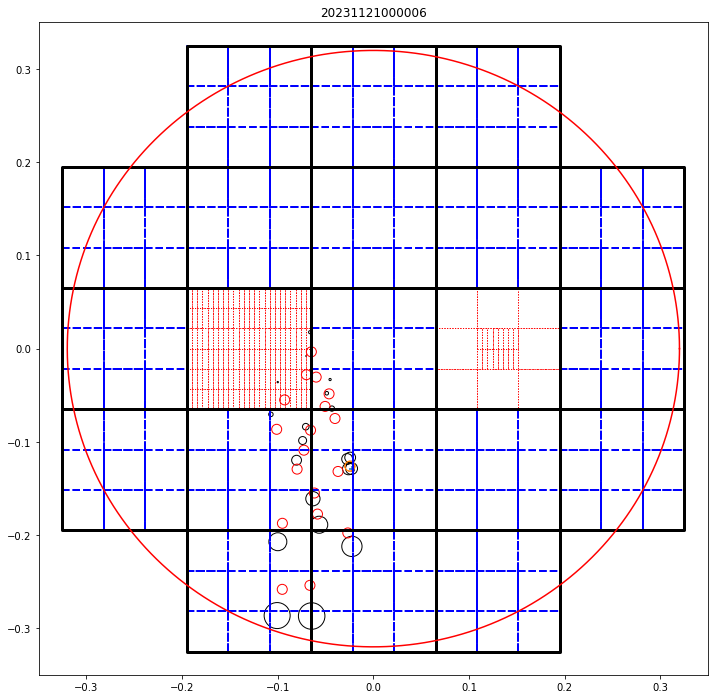

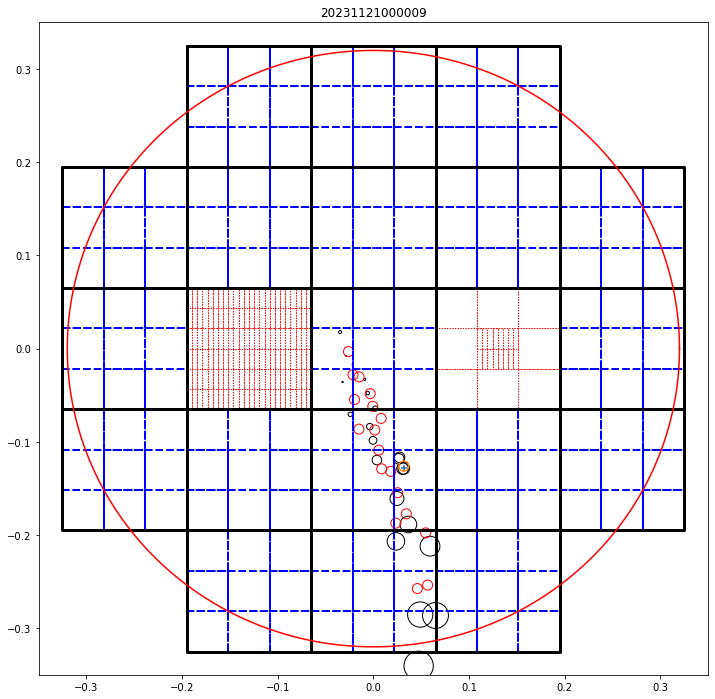

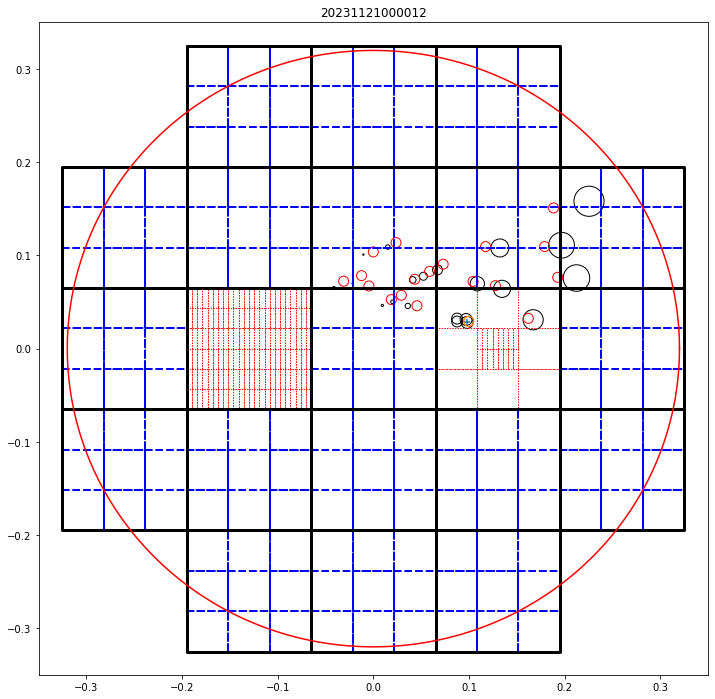

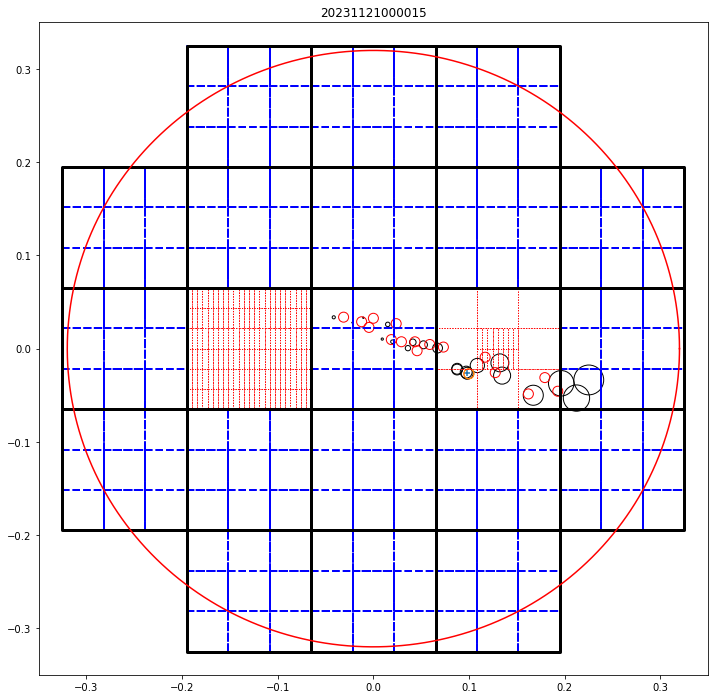

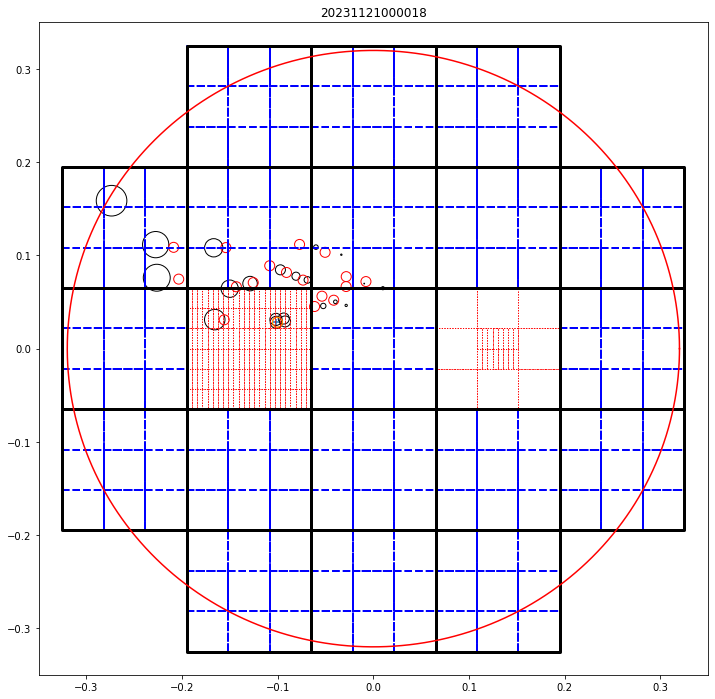

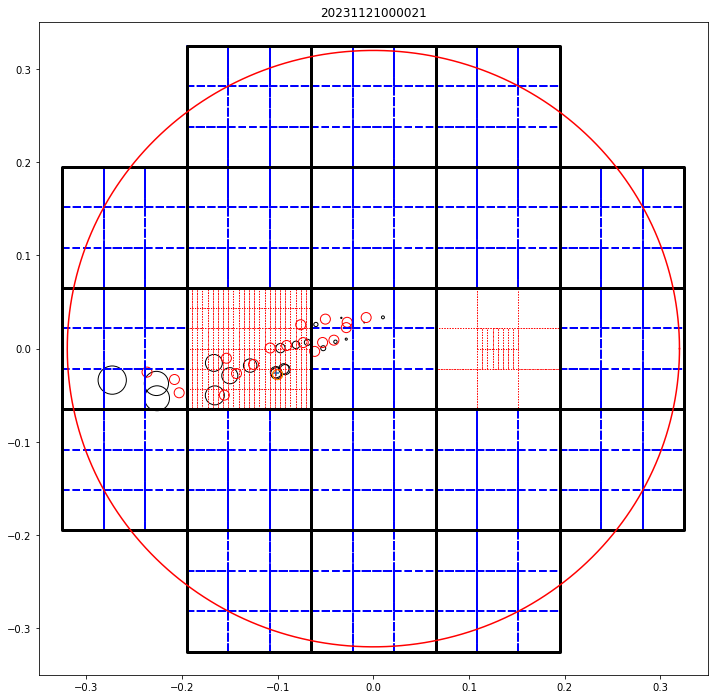

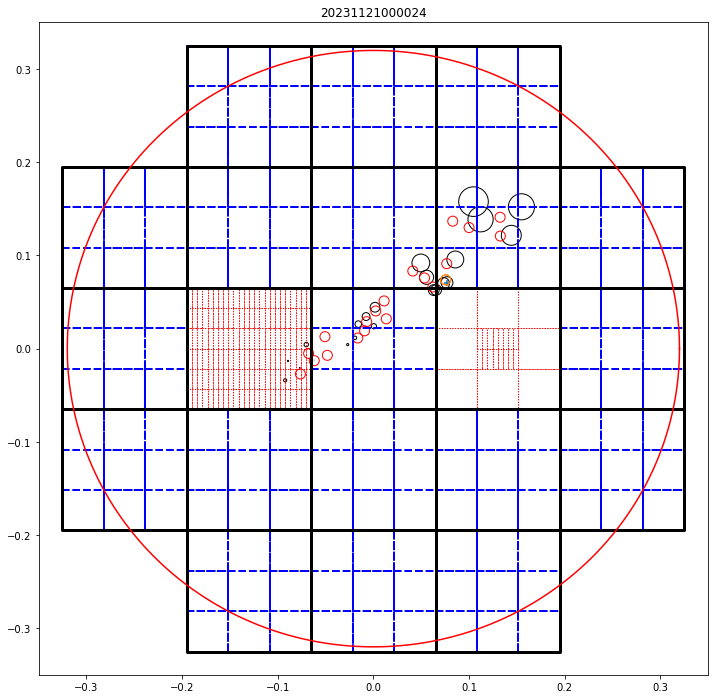

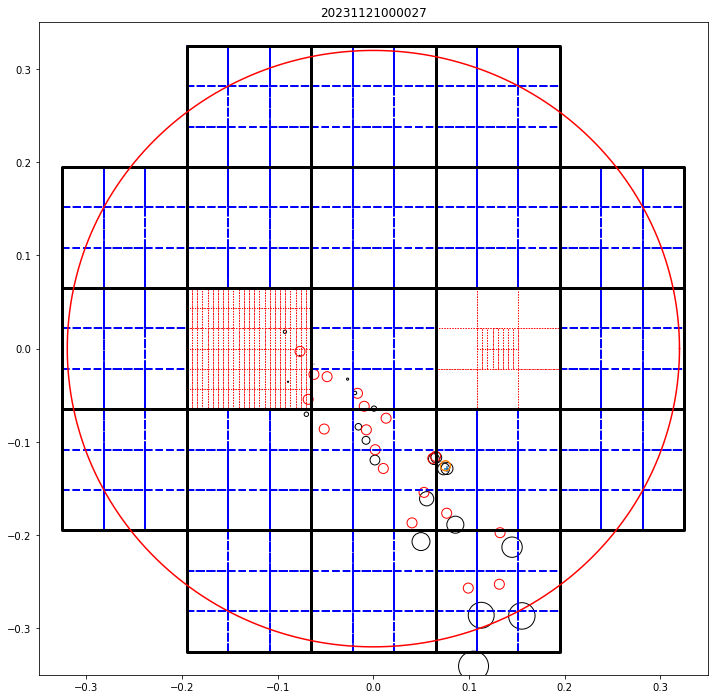

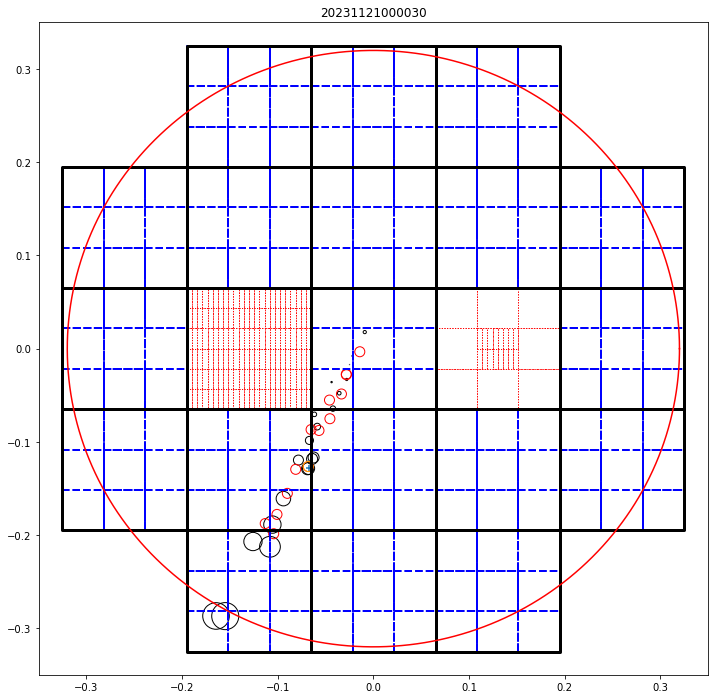

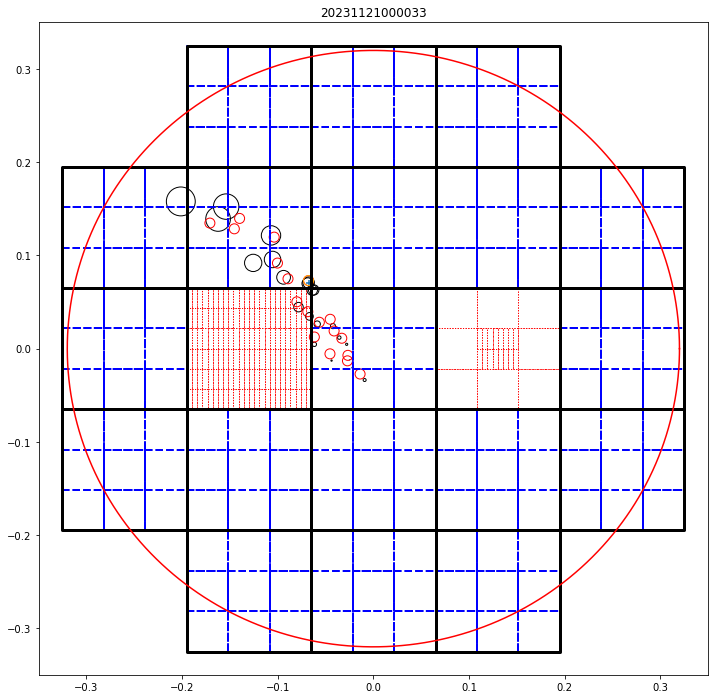

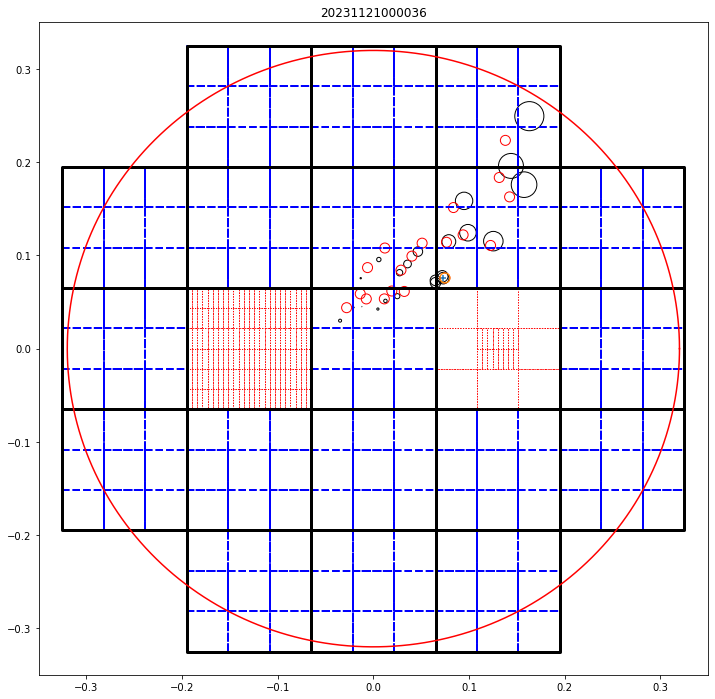

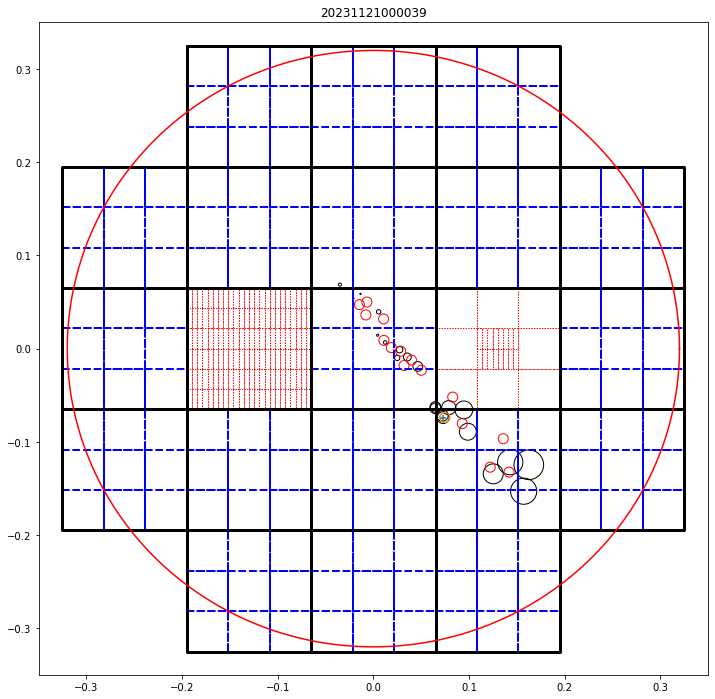

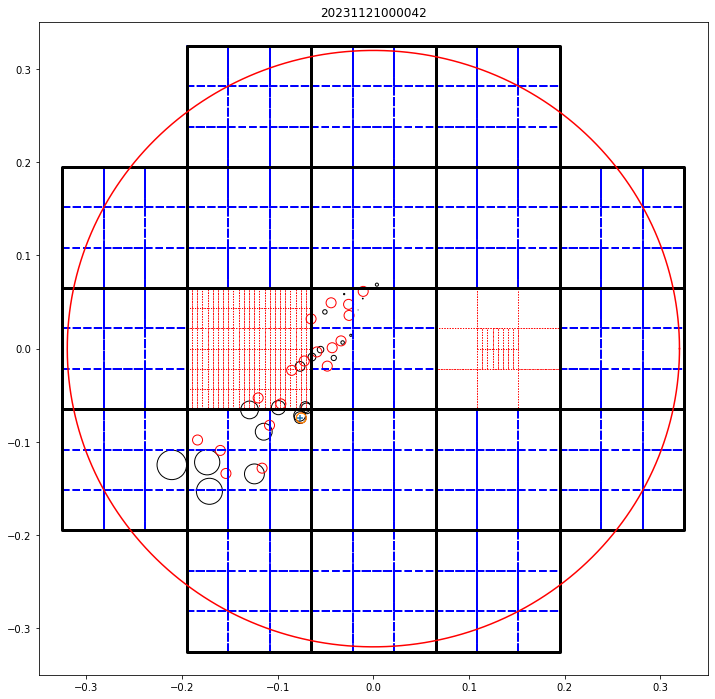

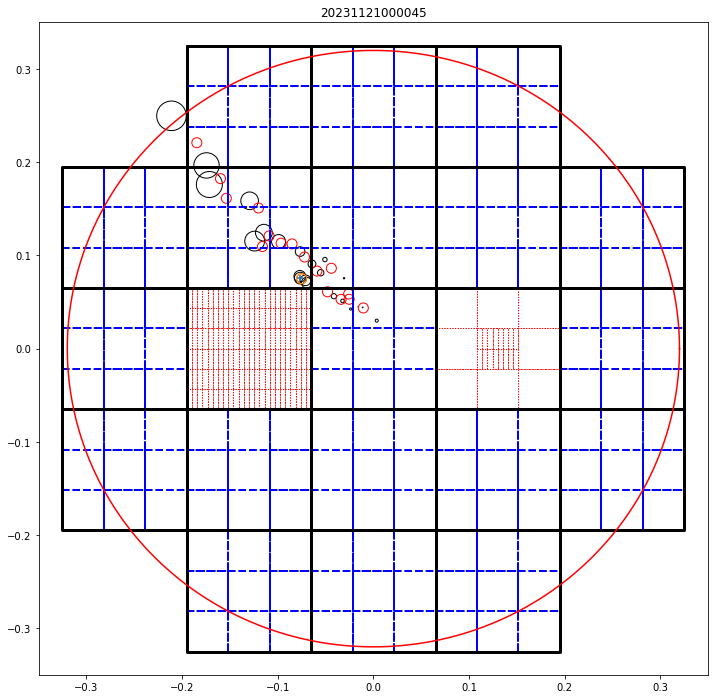

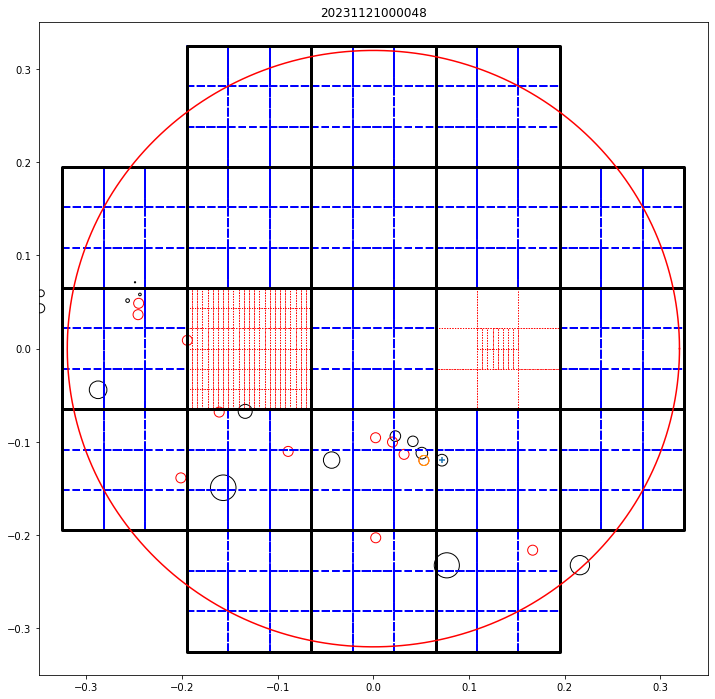

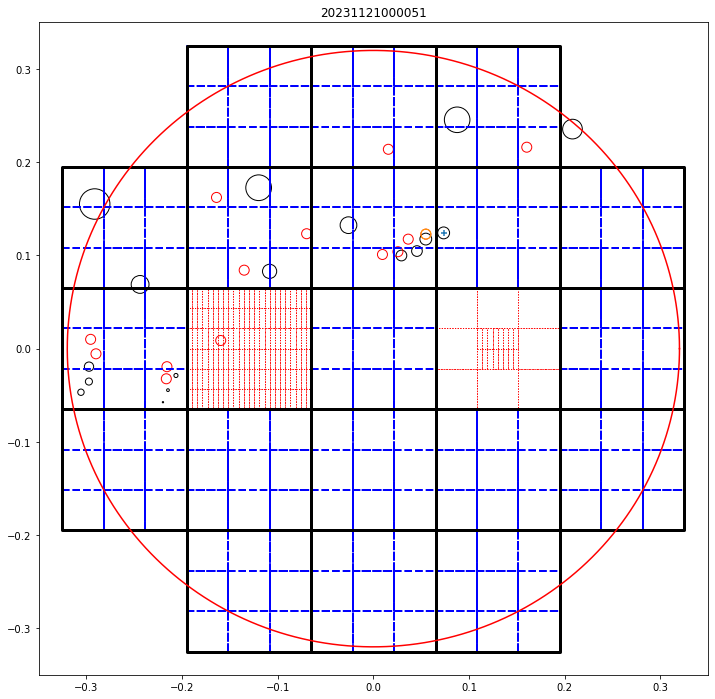

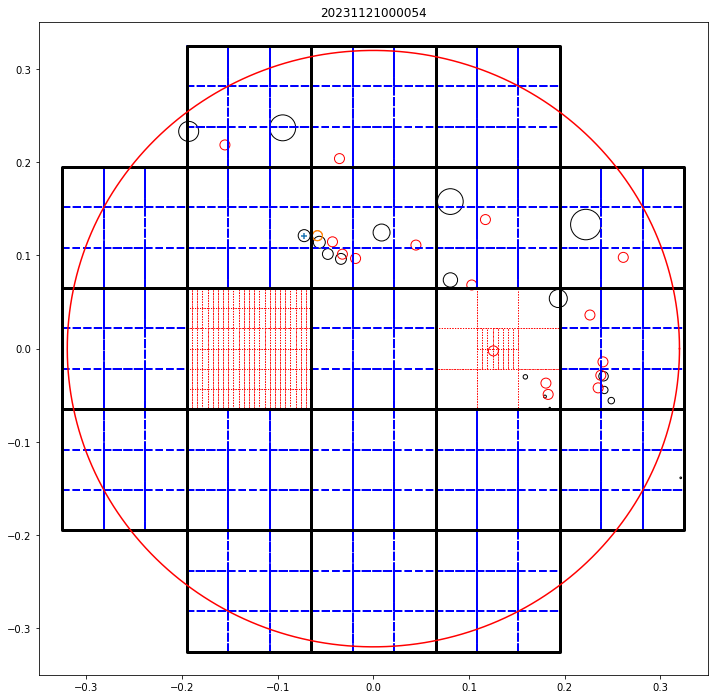

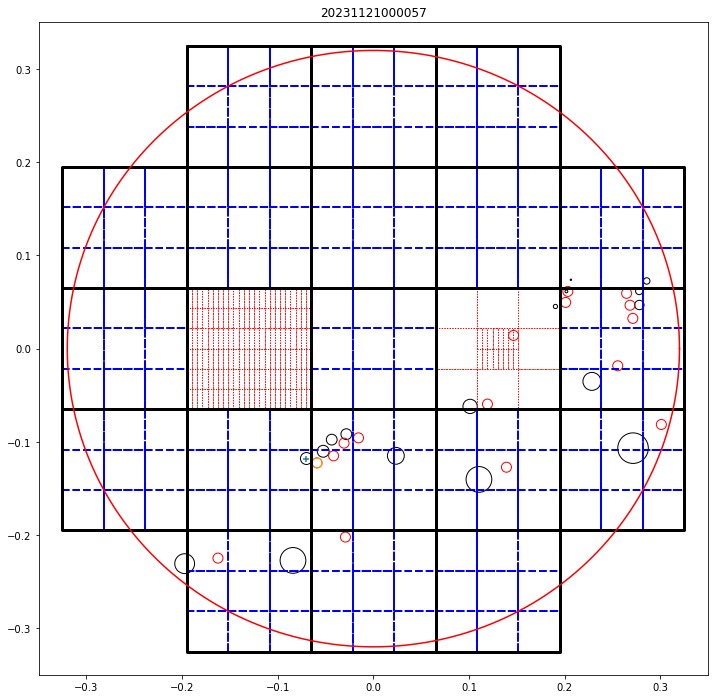

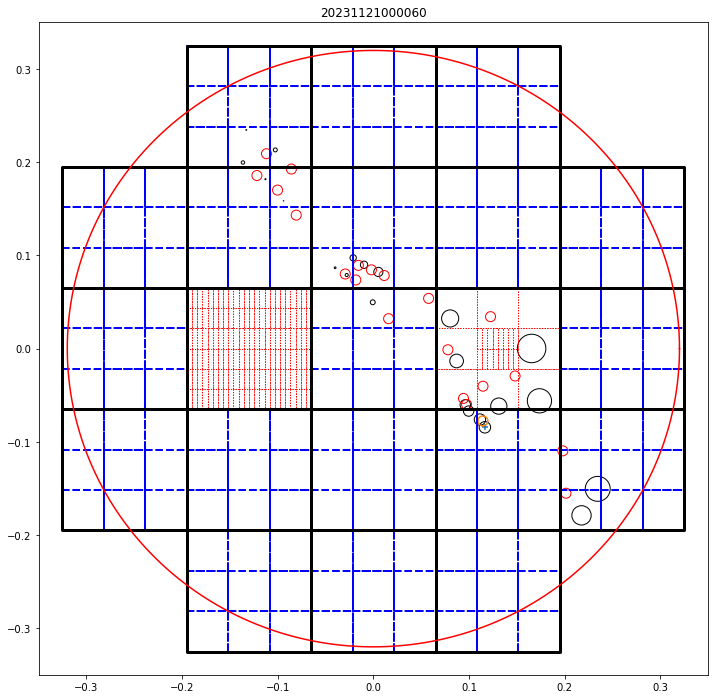

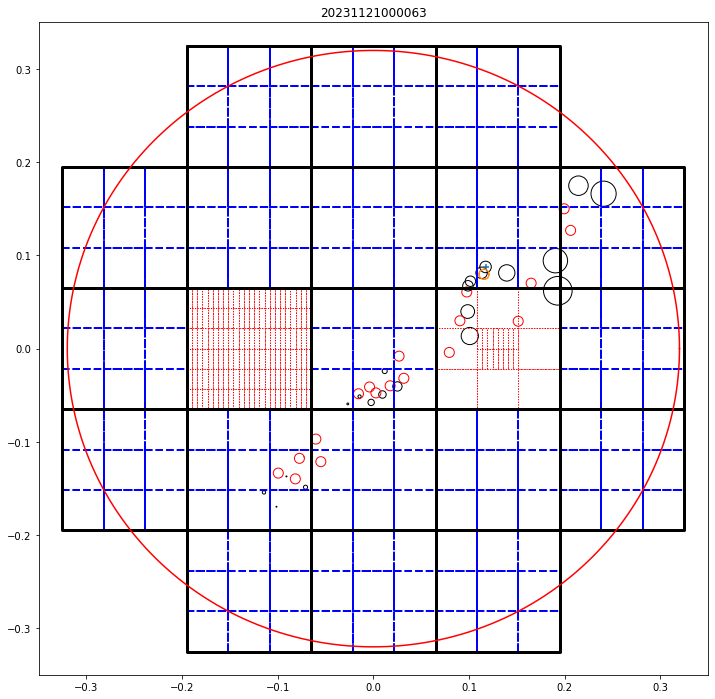

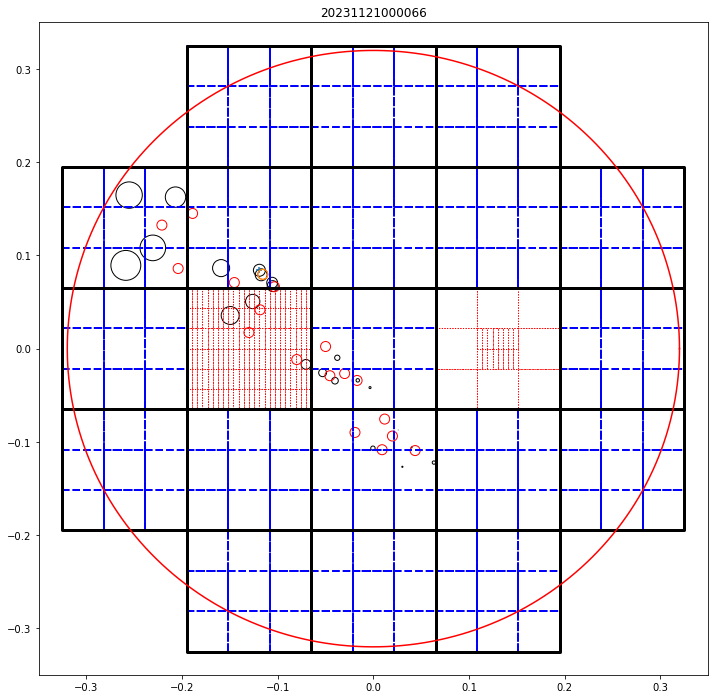

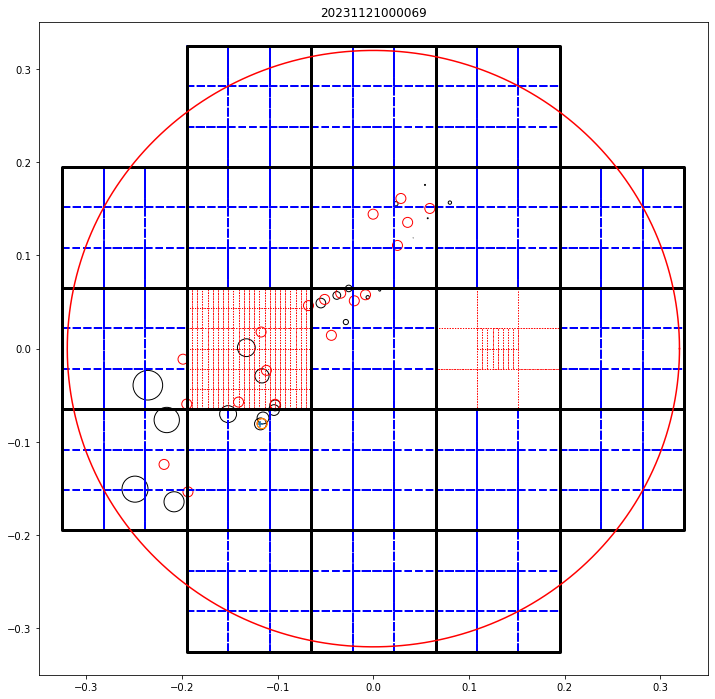

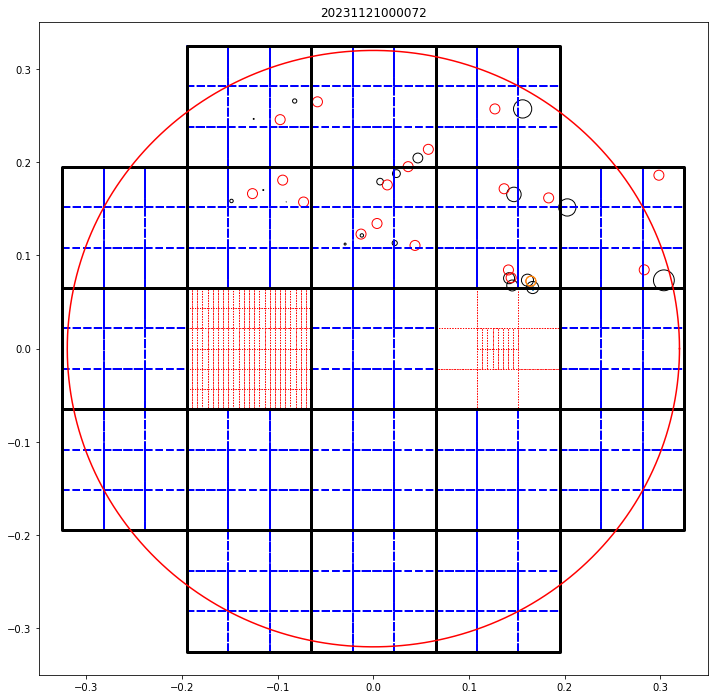

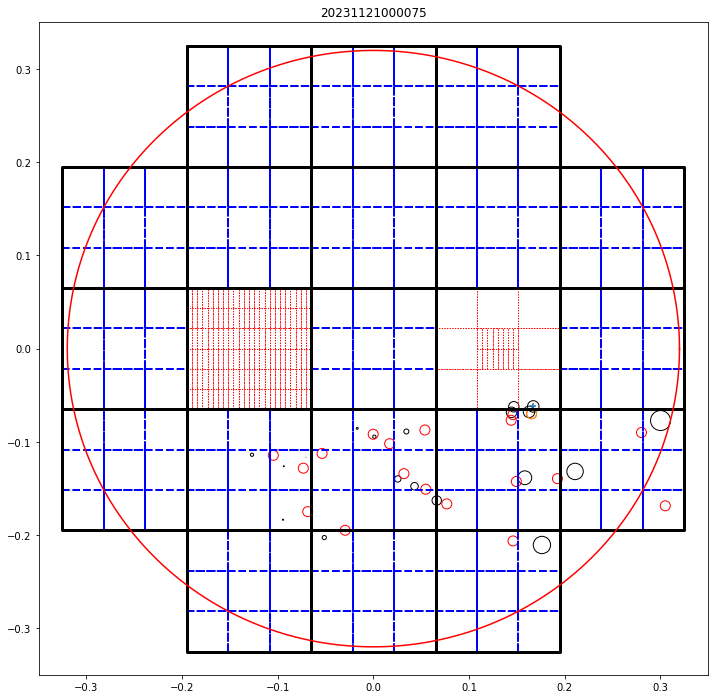

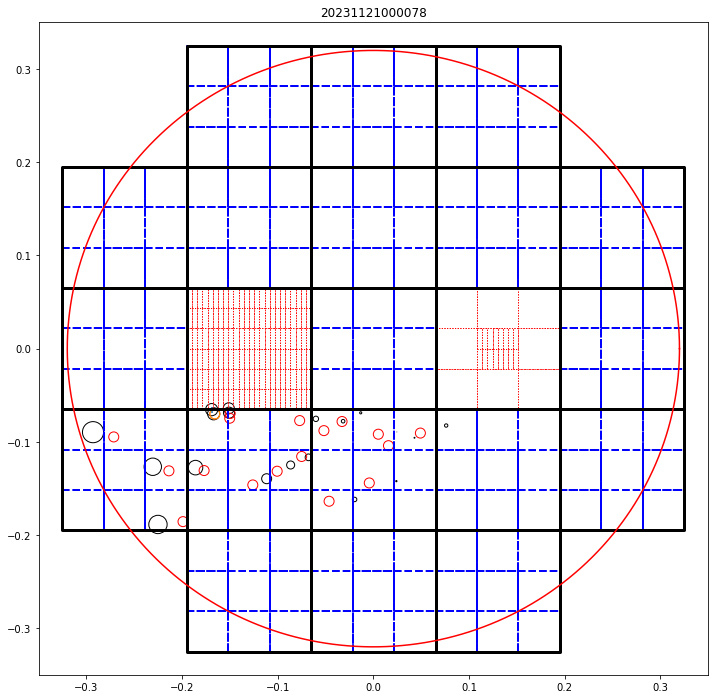

In [27]:
for i in range(3, 80, 3):
    print(f'20231121{i:06d}')
    compare_real_data_and_simulations(run=13579, exposure_id=f'20231121{i:06d}')